In [2]:
# ECM  Grib2  EPT,Wind天気図作成
#
#  2023/07/26 Ryuta Kurora
#
import math
import pygrib
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime
import sys
#
import metpy.calc as mpcalc
from metpy.units import units

In [3]:
# GRIB2データファイルの格納先フォルダー名
data_fld="./data/ecm/"
#
# ECMWF GRIB2の読み込む初期値の年月日時をUTCで指定する。
i_year =2023
i_month = 5
i_day = 23
i_hourZ = 18
#
# 予想時間を与える。
i_ft = 0
#
# EPTを算出する気圧面を指定
tagHp = 850
#
## GPVの切り出し領域の指定：(lonW,latS)-(lonE,latN)の矩形                                                                                                      
latS=-20
latN=80
lonW=70
lonE=190
#
# 描画する範囲の大まかな指定
## 描画指定
# 基準の経度  JAPAN:140 USA:270
set_central_longitude=140
flag_border=False
# 地図の描画範囲指定
n_area=1
if n_area == 0:
    i_area = [108, 156, 17, 55]  #FEAX 極東                                                                   
    str_area = ""
elif n_area == 1:
    i_area = [115, 151, 20, 50]  #fx85 日本付近                                                               
    str_area = "_j"
elif n_area == 2:
    i_area = [105,180,0,65]      #ASAS                                                                        
    str_area = "_a"
elif n_area == 9:
    set_central_longitude=270
    i_area = [238, 286, 17, 55]  # USA
    str_area = "_usa"
    lonW=210  # JAPAN 70
    lonE=330  # JAPAN 190
    flag_border=True
else:
    i_area = [108, 156, 17, 55]  #FEAX 極東                                                                   
    str_area = ""
#
# 緯線・経線の指定
dlon,dlat=10,10   # 10度ごとに
# 相当温位(等値線の間隔を指定)
levels_ept0  =np.arange(270, 390,  3) # 等値線                              
levels_ept0i =np.arange(270, 390,  3) # 等値線 数字                    
levels_ept1  =np.arange(270, 390, 15) # 等値線 太線                  
levels_eptf  =np.arange(270, 360,  3) # シェード用


In [4]:
# 読み込むGRIB2形式ECMWFのファイル名
#  ex.  20230520120000-12h-oper-fc.grib2
if i_hourZ==0 or i_hourZ==12:
    ecm_fn_t="{0:4d}{1:02d}{2:02d}{3:02d}0000-{4:d}h-oper-fc.grib2"
else:
    ecm_fn_t="{0:4d}{1:02d}{2:02d}{3:02d}0000-{4:d}h-scda-fc.grib2"
ecm_fn= ecm_fn_t.format(i_year,i_month,i_day,i_hourZ,i_ft)
#
# データOpen
grbs = pygrib.open(data_fld + ecm_fn)
#
# データ取得                                                                                                                       
grbHt = grbs(shortName="gh",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWu = grbs(shortName="u",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbWv = grbs(shortName="v",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbTm = grbs(shortName="t",typeOfLevel='isobaricInhPa',level=tagHp)[0]
grbRh = grbs(shortName="r",typeOfLevel='isobaricInhPa',level=tagHp)[0]
#
# データClose
grbs.close()
#
print(ecm_fn)
#
## データ切り出し                                                                                                                   
valHt, latHt, lonHt = grbHt.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWu, latWu, lonWu = grbWu.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valWv, latWv, lonWv = grbWv.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valTm, latTm, lonTm = grbTm.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)
valRh, latRh, lonRh = grbRh.data(lat1=latS,lat2=latN,lon1=lonW,lon2=lonE)

20230523180000-0h-scda-fc.grib2


In [5]:
## 算出のためにxarrayデータセットを作成                                                                                   
ds = xr.Dataset(
   {
       "Geopotential_height": (["lat", "lon"], valHt),                                                                        
       "u_wind": (["lat", "lon"], valWu),
       "v_wind": (["lat", "lon"], valWv),
       "Temperature": (["lat", "lon"], valTm),
       "RelativHumidity": (["lat", "lon"], valRh * 0.01)
   },
   coords={
       "time": np.array([grbHt.validDate]),
       "level": np.array(tagHp) * units.hPa,
       "lat": np.array(latHt[:,0]) * units('degrees_north'),
       "lon": np.array(lonHt[0,:]) * units('degrees_east')
   }
)
# 単位も入力する
ds['Geopotential_height'].attrs['units'] = 'm'
ds['u_wind'].attrs['units']='m/s'
ds['v_wind'].attrs['units']='m/s'
ds['Temperature'].attrs['units']='K'
ds['RelativHumidity'].attrs['units']=''
ds['level'].attrs['units'] = 'hPa'
ds['lat'].attrs['units'] = 'degrees_north'
ds['lon'].attrs['units'] = 'degrees_east'
#
# metpy仕様に変換
dsp= ds.metpy.parse_cf()
#
### 計算 
# 露点温度
dsp['dewpoint_temperature'] = mpcalc.dewpoint_from_relative_humidity(
    dsp['Temperature'],dsp['RelativHumidity'])
# 相当温位
dsp['Equivalent_Potential_temperature'] = mpcalc.equivalent_potential_temperature(
    dsp['level'],dsp['Temperature'],dsp['dewpoint_temperature'])

/Users/rkurora/opt/anaconda3/envs/metpy/lib/python3.11/site-packages/metpy/calc/thermo.py:1390: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


In [6]:
####  作図用処理                                                                                                           
## 年月日                                                                                                    
dt_v = grbHt.validDate
dt_i = grbHt.analDate
dt_str = (dt_i.strftime("%H00UTC%d%b%Y")).upper()
dt_str2 = dt_i.strftime("%Y%m%d%H")

output:ecm_2023052318UTC_FT000_ept850_j.png


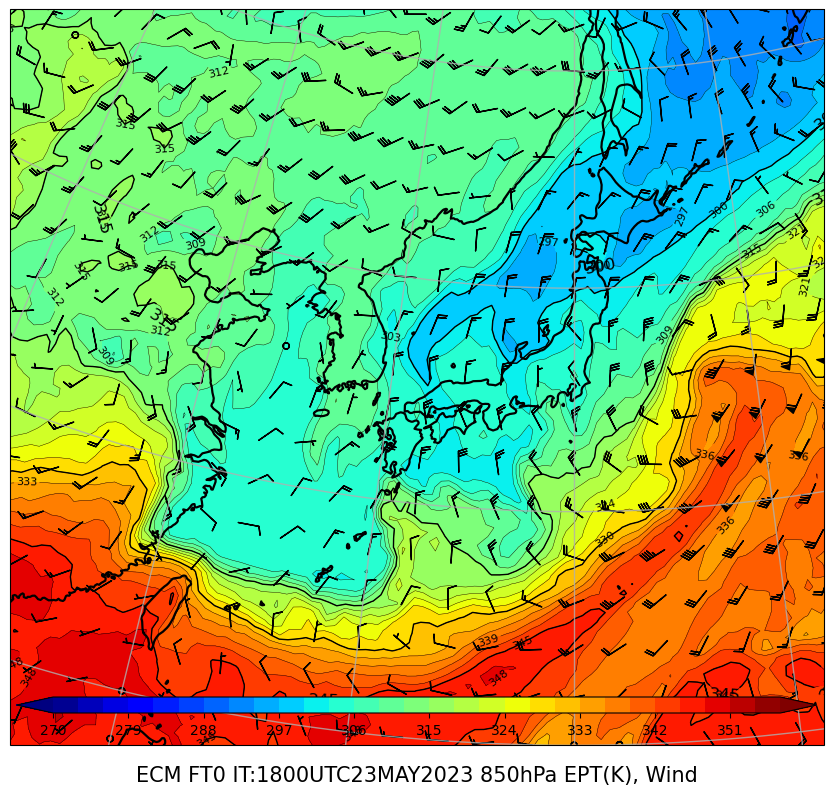

In [7]:
### 境界データ作成
# Make state boundaries feature
states_provinces = cfeature.NaturalEarthFeature(category='cultural',
                                                name='admin_1_states_provinces_lines',
                                                scale='50m', facecolor='none')
# Make country borders feature
country_borders = cfeature.NaturalEarthFeature(category='cultural',
                                               name='admin_0_countries',
                                               scale='50m', facecolor='none')
#
## 図法指定                                                                             
proj = ccrs.Stereographic(central_latitude=60, central_longitude=set_central_longitude)
latlon_proj = ccrs.PlateCarree()
## 図のSIZE指定inch                                                                        
fig = plt.figure(figsize=(10,8))
## 余白設定                                                                                
plt.subplots_adjust(left=0, right=1, bottom=0.06, top=0.98)                  
## 作図                                                                                    
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent(i_area, latlon_proj)
#
# EPT塗りつぶし
cnf_ept = ax.contourf(dsp['lon'], dsp['lat'], dsp['Equivalent_Potential_temperature'],
                      levels_eptf, cmap="jet", extend='both',
                      transform=latlon_proj )
# colorbarの位置と大きさ指定
#  add_axes([左端の距離, 下端からの距離, 横幅, 縦幅])
ax_ept = fig.add_axes([0.1, 0.1, 0.8, 0.02])
cb_ept = fig.colorbar(cnf_ept, orientation='horizontal', shrink=0.74,
                      aspect=40, pad=0.01, cax=ax_ept)
#
# EPT等値線 実線
cn_ept0 = ax.contour(dsp['lon'], dsp['lat'],
                     dsp['Equivalent_Potential_temperature'],
                     colors='black', linewidths=0.3, levels=levels_ept0,
                     transform=latlon_proj )
ax.clabel(cn_ept0, levels_ept0i, fontsize=8,
          inline=True, inline_spacing=5,
          fmt='%i', rightside_up=True, colors='black')
cn_ept1 = ax.contour(dsp['lon'], dsp['lat'],
                     dsp['Equivalent_Potential_temperature'],
                     colors='black', linewidths=1.0, levels=levels_ept1,
                     transform=latlon_proj )
ax.clabel(cn_ept1, levels_ept1, fontsize=12,
          inline=True, inline_spacing=5,
          fmt='%i', rightside_up=True, colors='black')

#
## 海岸線
ax.coastlines(resolution='50m', linewidth=1.6) # 海岸線の解像度を上げる  
if (flag_border):
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.5)
    ax.add_feature(country_borders, edgecolor='black', linewidth=0.5)
#
# グリッド線を引く                                                               
xticks=np.arange(0,360,dlon)
yticks=np.arange(-90,90.1,dlat)
gl = ax.gridlines(crs=ccrs.PlateCarree()
         , draw_labels=False
         , linewidth=1, alpha=0.8)
gl.xlocator = mticker.FixedLocator(xticks)
gl.ylocator = mticker.FixedLocator(yticks)
#
## 風                                                           
wind_slice = (slice(None, None, 5), slice(None, None, 5))
ax.barbs(dsp['lon'][wind_slice[0]], dsp['lat'][wind_slice[1]],    
         dsp['u_wind'].values[wind_slice] * 1.944,
         dsp['v_wind'].values[wind_slice] * 1.944,
         length=5.5,
         pivot='middle', color='black', transform=latlon_proj)
#
## 図の説明
fig.text(0.5,0.01,"ECM FT{0:d} IT:".format(i_ft)+dt_str+
         " {0}hPa EPT(K), Wind".format(tagHp) ,
         ha='center',va='bottom', size=15)
#
## file出力
output_fig_nm="ecm_{0}UTC_FT{1:03d}_ept{2}{3}.png".format(dt_str2,i_ft,tagHp,str_area)
plt.savefig(output_fig_nm)
print("output:{}".format(output_fig_nm))
#
## 表示
plt.show()